In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# 1. Load data
data = pd.read_csv('Kab_Langkat.csv')

In [ ]:
data = pd.DataFrame(data)

In [ ]:
print("Data Stunting Kabupaten Langkat:")
data

Data Stunting Kabupaten Langkat:


,No,ID BPS,ID Dagri,Nama Desa,Jumlah Balita,Stunting Pendek,Stunting Sangat Pendek,Prevalensi (%)
0,1,1213010001,1205012014,Batu Jong Jong,160,0,3,1.9
1,2,1213010002,1205012002,Lau Damak,162,0,6,3.7
2,3,1213010003,1205012003,Timbang Lawan,306,7,17,7.8
3,4,1213010004,1205012004,Sampe Raya,275,0,2,0.7
4,5,1213010005,1205012009,Bukit Lawang,229,18,14,14.0
...,...,...,...,...,...,...,...,...
272,273,1213201004,1205232004,Perkebunan Perapen,75,0,1,1.3
273,274,1213201005,1205232005,Limau Mungkur,124,0,0,0.0
274,275,1213201006,1205232003,Perkebunan Damar Condong,146,0,0,0.0
275,276,1213201007,1205232002,Damar Condong,111,4,5,8.1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   No                      277 non-null    int64  
 1   ID BPS                  277 non-null    int64  
 2   ID Dagri                277 non-null    int64  
 3   Nama Desa               277 non-null    object 
 4   Jumlah Balita           277 non-null    int64  
 5   Stunting Pendek         277 non-null    int64  
 6   Stunting Sangat Pendek  277 non-null    int64  
 7   Prevalensi (%)          277 non-null    float64
dtypes: float64(1), int64(6), object(1)
memory usage: 17.4+ KB


In [ ]:
# 3. Menampilkan data persentase stunting
print("Data Persentase Stunting:")
data[['Nama Desa', 'Jumlah Balita', 'Stunting Pendek', 'Stunting Sangat Pendek', 'Prevalensi (%)']].head(10)

Data Persentase Stunting:


,Nama Desa,Jumlah Balita,Stunting Pendek,Stunting Sangat Pendek,Prevalensi (%)
0,Batu Jong Jong,160,0,3,1.9
1,Lau Damak,162,0,6,3.7
2,Timbang Lawan,306,7,17,7.8
3,Sampe Raya,275,0,2,0.7
4,Bukit Lawang,229,18,14,14.0
5,Perkebunan Bungara,256,0,4,1.6
6,Pekan Bahorok,236,1,7,3.4
7,Empus,186,3,9,6.5
8,Perkebunan Turangi,178,4,11,8.4
9,Simpang Pulau Rambung,161,0,2,1.2


In [ ]:
# 4. Normalisasi data menggunakan Min-Max Scaling
scaler = MinMaxScaler()
data[['Prevalensi Norm', 'Jumlah Balita Norm']] = scaler.fit_transform(data[['Prevalensi (%)', 'Jumlah Balita']])

print("\nData Setelah Normalisasi:")
data[['Nama Desa', 'Prevalensi (%)', 'Prevalensi Norm', 'Jumlah Balita', 'Jumlah Balita Norm']].head(10)


Data Setelah Normalisasi:


,Nama Desa,Prevalensi (%),Prevalensi Norm,Jumlah Balita,Jumlah Balita Norm
0,Batu Jong Jong,1.9,0.073930,160,0.063718
1,Lau Damak,3.7,0.143969,162,0.065217
2,Timbang Lawan,7.8,0.303502,306,0.173163
3,Sampe Raya,0.7,0.027237,275,0.149925
4,Bukit Lawang,14.0,0.544747,229,0.115442
5,Perkebunan Bungara,1.6,0.062257,256,0.135682
6,Pekan Bahorok,3.4,0.132296,236,0.120690
7,Empus,6.5,0.252918,186,0.083208
8,Perkebunan Turangi,8.4,0.326848,178,0.077211
9,Simpang Pulau Rambung,1.2,0.046693,161,0.064468


In [ ]:
# 5. Fungsi untuk menghitung jarak Euclidean
def hitung_jarak_euclidean(df, desa1, desa2):
    row1 = df[df['Nama Desa'] == desa1][['Prevalensi Norm', 'Jumlah Balita Norm']].values[0]
    row2 = df[df['Nama Desa'] == desa2][['Prevalensi Norm', 'Jumlah Balita Norm']].values[0]
    distance = np.sqrt((row1[0] - row2[0])**2 + (row1[1] - row2[1])**2)
    return distance

# Contoh perhitungan jarak Euclidean
desa_a = 'Timbang Lawan'
desa_b = 'Batu Jong Jong'
jarak = hitung_jarak_euclidean(data, desa_a, desa_b)
print(f"\nJarak Euclidean antara {desa_a} dan {desa_b}: {jarak:.3f}")



Jarak Euclidean antara Timbang Lawan dan Batu Jong Jong: 0.254


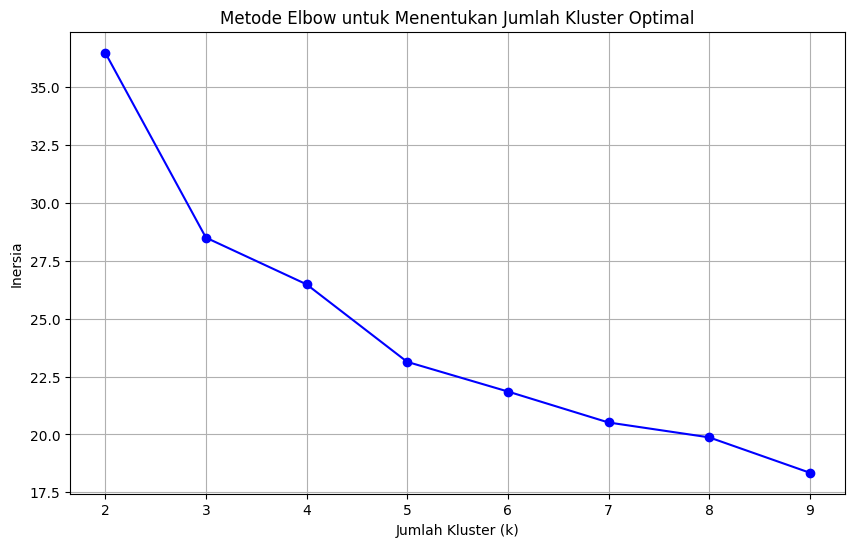

In [ ]:
#6. Pemilihan Jumlah Kluster Optimal dengan Metode Elbow
# Menghitung inersia untuk berbagai nilai k
# Menyiapkan fitur untuk clustering
X = data[['Prevalensi Norm', 'Jumlah Balita Norm']].values


inertia = []
k_range = range(2, 10)
for k in k_range:
    kmedoids = KMedoids(n_clusters=k, random_state=42)
    kmedoids.fit(X)
    inertia.append(kmedoids.inertia_)

# Visualisasi metode elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Inersia')
plt.title('Metode Elbow untuk Menentukan Jumlah Kluster Optimal')
plt.xticks(k_range)
plt.grid()
plt.show()

Silhouette Score untuk k=3: 0.410


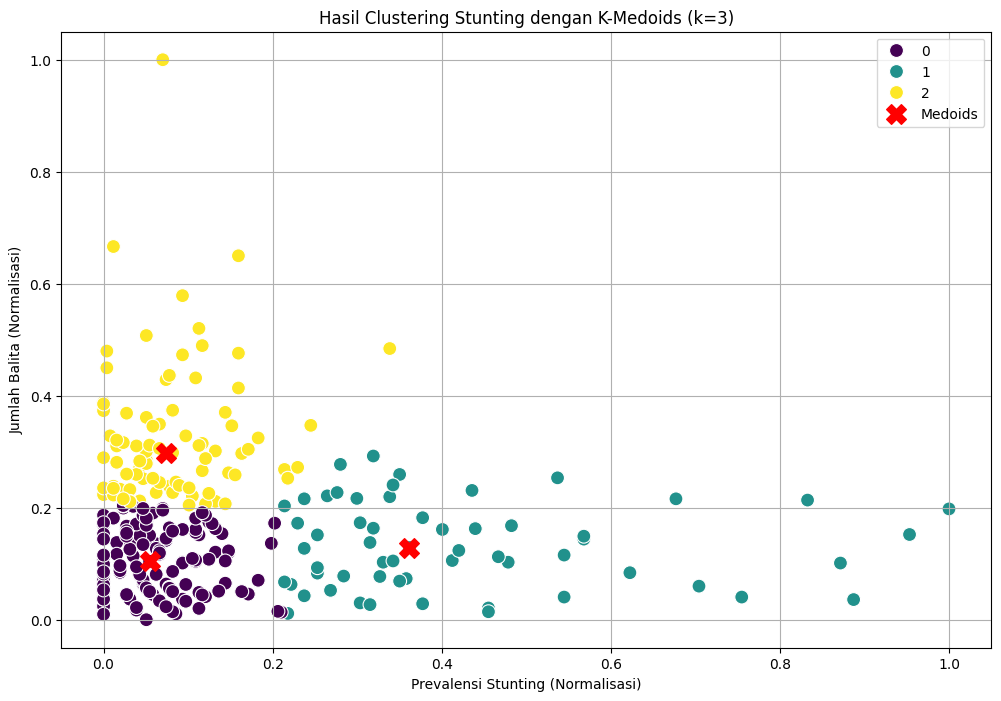

In [ ]:
#7. Implementasi K-Medoids dengan 3 Kluster
# Melakukan clustering dengan K-Medoids (k=3)
k = 3
kmedoids = KMedoids(n_clusters=k, random_state=42)
clusters = kmedoids.fit_predict(X)

# Menambahkan hasil clustering ke dataframe
data['Cluster'] = clusters

# Menghitung silhouette score
silhouette_avg = silhouette_score(X, clusters)
print(f"Silhouette Score untuk k={k}: {silhouette_avg:.3f}")

# Visualisasi hasil clustering
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Prevalensi Norm', y='Jumlah Balita Norm', hue='Cluster', 
                data=data, palette='viridis', s=100)
plt.scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1],
            marker='X', s=200, c='red', label='Medoids')
plt.xlabel('Prevalensi Stunting (Normalisasi)')
plt.ylabel('Jumlah Balita (Normalisasi)')
plt.title('Hasil Clustering Stunting dengan K-Medoids (k=3)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#8. Analisis Karakteristik Kluster
# Analisis karakteristik setiap kluster
cluster_stats = data.groupby('Cluster').agg({
    'Prevalensi (%)': ['mean', 'median', 'min', 'max'],
    'Jumlah Balita': ['mean', 'median', 'min', 'max'],
    'Nama Desa': 'count'
}).reset_index()

print("\nStatistik Deskriptif per Kluster:")
print(cluster_stats)

# Menampilkan contoh desa dari setiap kluster
print("\nContoh Desa dari Setiap Kluster:")
for cluster in sorted(data['Cluster'].unique()):
    sample = data[data['Cluster'] == cluster].sample(3)
    print(f"\nKluster {cluster}:")
    print(sample[['Nama Desa', 'Prevalensi (%)', 'Jumlah Balita']])


Statistik Deskriptif per Kluster:
  Cluster Prevalensi (%)                   Jumlah Balita                    \
                    mean median  min   max          mean median  min   max   
0       0       1.643846   1.40  0.0   5.4    216.384615  215.5   75   347   
1       1      10.759322   9.00  5.5  25.7    251.881356  245.0   90   465   
2       2       2.126136   1.85  0.0   8.7    506.920455  466.0  348  1409   

  Nama Desa  
      count  
0       130  
1        59  
2        88  

Contoh Desa dari Setiap Kluster:

Kluster 0:
           Nama Desa  Prevalensi (%)  Jumlah Balita
258  Pangkalan Siata             0.7            287
167    Tanjung Mulia             4.4            136
271  Pematang Tengah             5.3             95

Kluster 1:
       Nama Desa  Prevalensi (%)  Jumlah Balita
129   Paya Tusan             5.5            165
216   Pasar Rawa             8.8            396
126  Stabat Lama             7.2            445

Kluster 2:
        Nama Desa  Prevalensi (%) 


Wilayah dengan Prevalensi Stunting Tinggi:
            Nama Desa  Prevalensi (%)  Jumlah Balita
36            Turangi             5.4             93
271   Pematang Tengah             5.3             95
242  Tangkahan Durian             5.2            305
148         Sukaramai             5.1            257
10            Sematar             4.7            169
167     Tanjung Mulia             4.4            136
218   Bukit Mengkirai             4.2            142
28         Aman Damai             3.8            235
69         Mekar Jaya             3.8            239
176        Cinta Raja             3.7            215


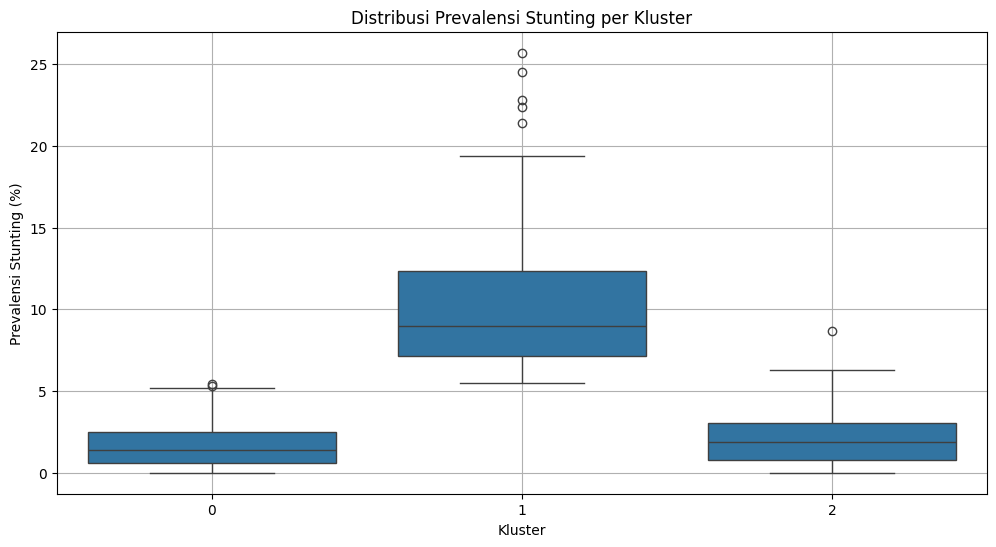

In [ ]:
#9. Identifikasi Faktor Dominan
# Analisis faktor dominan berdasarkan kluster
high_stunting = data[data['Cluster'] == data['Cluster'].value_counts().idxmax()]

print("\nWilayah dengan Prevalensi Stunting Tinggi:")
print(high_stunting[['Nama Desa', 'Prevalensi (%)', 'Jumlah Balita']].sort_values('Prevalensi (%)', ascending=False).head(10))

# Visualisasi distribusi prevalensi per kluster
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Prevalensi (%)', data=data)
plt.title('Distribusi Prevalensi Stunting per Kluster')
plt.xlabel('Kluster')
plt.ylabel('Prevalensi Stunting (%)')
plt.grid()
plt.show()